# SEG Embedding & Representation Analysis — ESOL

**Zentrale Frage:** Warum funktioniert eine *gefrorene, zufällig initialisierte* Text-Projektion besser als eine gelernte?

## Analysen

1. **Multi-Seed Training** — 4 Configs × 6 Seeds: frozen/unfrozen × xavier/kaiming
2. **Effective Rank** — SVD-Analyse der Graph- und Text-Repräsentationen pro Config
3. **Embedding-Stabilität** — Wie deterministisch sind die gelernten Embeddings über Seeds?
4. **Tanimoto ↔ Embedding-Distanz** — Korreliert molekulare Ähnlichkeit mit Embedding-Nähe?
5. **Learning Curves** — Overfitting-Verhalten frozen vs unfrozen

In [16]:
# === Setup ===
import sys
import random
from pathlib import Path
workspace_root = Path.cwd().parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import numpy as np
import pandas as pd
import torch
import deepchem as dc
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Dict, List, Any, Optional
from itertools import product
from scipy import stats
from scipy.spatial.distance import pdist, squareform

from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph
from utils.batched_mol_graph import batch_graphs
from models import SEGPredictor, SEGPredictorConfig

print(f"Workspace: {workspace_root}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Workspace: c:\Users\robsc\Home\Dev\molfusion2
PyTorch: 2.6.0+cu124, CUDA: True


In [17]:
# === Load Data ===
tasks, datasets, _ = dc.molnet.load_delaney(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

TRAIN_SMILES = list(train_dc.ids)
TRAIN_Y = train_dc.y.reshape(-1).astype(np.float32)
VALID_SMILES = list(valid_dc.ids)
VALID_Y = valid_dc.y.reshape(-1).astype(np.float32)
TEST_SMILES = list(test_dc.ids)
TEST_Y = test_dc.y.reshape(-1).astype(np.float32)

# Text embeddings
COT_EMB_DIR = workspace_root / "cache" / "cot_embeddings"
npz_path = COT_EMB_DIR / "solubility_fast_text_embeddings_compact.npz"
cache = EfficientEmbeddingCache.load(npz_path)

all_smiles = TRAIN_SMILES + VALID_SMILES + TEST_SMILES
all_emb = torch.from_numpy(cache.get_batch(all_smiles))
n_train, n_valid = len(TRAIN_SMILES), len(VALID_SMILES)
TRAIN_TEXT_EMB = all_emb[:n_train]
VALID_TEXT_EMB = all_emb[n_train:n_train + n_valid]
TEST_TEXT_EMB = all_emb[n_train + n_valid:]

print(f"Train: {n_train} | Valid: {n_valid} | Test: {len(TEST_SMILES)}")
print(f"Text embeddings: {TRAIN_TEXT_EMB.shape[1]}D")

Loading embeddings from solubility_fast_text_embeddings_compact.npz...
  Loaded 1128 entries, dim=3072
  Memory mode: mapped
Train: 902 | Valid: 113 | Test: 113
Text embeddings: 3072D


In [18]:
# === Helper Functions ===

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true, y_pred = np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot if ss_tot > 0 else 0)
    return {"rmse": rmse, "mae": mae, "r2": r2}


def effective_rank(S: np.ndarray) -> float:
    """Entropy-based effective rank from singular values."""
    S_prob = (S**2) / np.sum(S**2)
    S_prob = S_prob[S_prob > 1e-10]
    return float(np.exp(-np.sum(S_prob * np.log(S_prob))))


def extract_graph_embeddings(model: SEGPredictor, smiles_list: List[str], batch_size: int = 32) -> np.ndarray:
    """Extract graph-level embeddings (after pooling, before fusion)."""
    model._encoder.eval()
    model._pooling.eval()
    embeddings = []
    
    valid_graphs = []
    for smi in smiles_list:
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
        except Exception:
            continue
    
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk = valid_graphs[start:start + batch_size]
            bg = batch_graphs(chunk)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            embeddings.append(graph_emb.cpu().numpy())
    
    return np.vstack(embeddings)


def extract_projected_text_embeddings(model: SEGPredictor, text_emb: torch.Tensor) -> np.ndarray:
    """Extract text embeddings after projection layer."""
    if model._text_proj is not None:
        model._text_proj.eval()
        with torch.no_grad():
            projected = model._text_proj(text_emb.to(model.device))
        return projected.cpu().numpy()
    return text_emb.numpy()


def extract_fused_embeddings(model: SEGPredictor, smiles_list: List[str], 
                              text_emb: torch.Tensor, batch_size: int = 32) -> np.ndarray:
    """Extract fused embeddings (graph + text, after fusion layer)."""
    model._encoder.eval()
    model._pooling.eval()
    model._fusion.eval()
    if model._text_proj is not None:
        model._text_proj.eval()
    
    embeddings = []
    valid_graphs = []
    valid_text = []
    
    for i, smi in enumerate(smiles_list):
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
            valid_text.append(text_emb[i])
        except Exception:
            continue
    
    valid_text_t = torch.stack(valid_text)
    
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk_graphs = valid_graphs[start:start + batch_size]
            chunk_text = valid_text_t[start:start + batch_size].to(model.device)
            
            bg = batch_graphs(chunk_graphs)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            
            if model._text_proj is not None:
                chunk_text = model._text_proj(chunk_text)
            
            fused = model._fusion(graph_emb, chunk_text)
            embeddings.append(fused.cpu().numpy())
    
    return np.vstack(embeddings)


def train_and_collect(config: Dict[str, Any], seed: int, verbose: bool = False) -> Dict[str, Any]:
    """Train a model and collect all embeddings + metrics."""
    set_seed(seed)
    
    seg_config = SEGPredictorConfig(
        hidden_channels=config.get("hidden_channels", 64),
        K=config.get("K", 3),
        num_layers=config.get("num_layers", 2),
        dropout=config.get("dropout", 0.3),
        pool=config.get("pool", "sum"),
        set2set_processing_steps=config.get("set2set_processing_steps", 6),
        text_embedding_dim=3072,
        text_projection_dim=config.get("text_projection_dim", 32),
        text_proj_init=config.get("text_proj_init", "xavier"),
        text_proj_init_gain=config.get("text_proj_init_gain", 0.1),
        freeze_text_proj=config.get("freeze_text_proj", True),
        fusion=config.get("fusion", "cross_mha"),
        fusion_dim=config.get("fusion_dim", 32),
        fusion_dropout=config.get("fusion_dropout", 0.4),
        head_type=config.get("head_type", "mlp"),
        head_hidden_dim=config.get("head_hidden_dim", 32),
        head_dropout=config.get("head_dropout", 0.5),
    )
    
    seg = SEGPredictor(config=seg_config)
    
    history = seg.fit(
        smiles_list=TRAIN_SMILES,
        labels=TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES,
        val_labels=VALID_Y.tolist(),
        text_embeddings=TRAIN_TEXT_EMB,
        val_text_embeddings=VALID_TEXT_EMB,
        num_epochs=config.get("num_epochs", 200),
        batch_size=config.get("batch_size", 32),
        learning_rate=config.get("learning_rate", 5e-4),
        weight_decay=config.get("weight_decay", 1e-1),
        patience=config.get("patience", 30),
        scheduler=config.get("scheduler", "plateau"),
        scheduler_patience=config.get("scheduler_patience", 5),
        scheduler_factor=config.get("scheduler_factor", 0.5),
        min_lr=config.get("min_lr", 1e-6),
        grad_clip=config.get("grad_clip", None),
        seed=seed,
        verbose=verbose,
    )
    
    # Test metrics
    preds = seg.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT_EMB)
    metrics = regression_metrics(TEST_Y, preds)
    
    # Extract embeddings on test set
    graph_emb = extract_graph_embeddings(seg, TEST_SMILES)
    text_proj_emb = extract_projected_text_embeddings(seg, TEST_TEXT_EMB)
    fused_emb = extract_fused_embeddings(seg, TEST_SMILES, TEST_TEXT_EMB)
    
    # SVD analysis
    _, S_graph, _ = np.linalg.svd(graph_emb, full_matrices=False)
    _, S_fused, _ = np.linalg.svd(fused_emb, full_matrices=False)
    
    # Text projection weight SVD (if exists)
    text_proj_weight_S = None
    if seg._text_proj is not None:
        W = seg._text_proj[0].weight.detach().cpu().numpy()
        _, text_proj_weight_S, _ = np.linalg.svd(W, full_matrices=False)
    
    return {
        "seed": seed,
        "metrics": metrics,
        "history": history,
        "model": seg,
        "graph_emb": graph_emb,
        "text_proj_emb": text_proj_emb,
        "fused_emb": fused_emb,
        "S_graph": S_graph,
        "S_fused": S_fused,
        "text_proj_weight_S": text_proj_weight_S,
    }


print("✓ Helper functions loaded")

✓ Helper functions loaded


---
## 0. Baseline-Vergleich: Komponentenanalyse

Bevor wir frozen vs learned analysieren, stellen wir die **Grundfrage**: Wie wichtig sind Graph- und Text-Komponente überhaupt?

| Baseline | Beschreibung |
|----------|-------------|
| **Random Forest (ECFP)** | Klassischer ML-Baseline auf Morgan-Fingerprints (2048 bit) |
| **ChebNet only** | Nur Graph-Encoder, kein Text — isoliert den GNN-Beitrag |
| **Text only (MLP)** | Nur Text-Embeddings (3072D) → MLP — isoliert den LLM-Beitrag |
| **SEG (frozen)** | Voller SEG Predictor mit frozen text\_proj (bestes Setup) |
| **SEG (learned)** | Voller SEG Predictor mit learned text\_proj |

4 Seeds pro Baseline, scaffold split.

Features: ECFP=2048 + Descriptors=217 = 2265 total
  RF seed=42: RMSE=0.5319
  RF seed=113: RMSE=0.5285
  RF seed=456: RMSE=0.5336
  RF seed=789: RMSE=0.5367
  RF Mean RMSE: 0.5327±0.0029

  ChebNet seed=42: RMSE=0.5080
  ChebNet seed=113: RMSE=0.5106
  ChebNet seed=456: RMSE=0.4850
  ChebNet seed=789: RMSE=0.5064
  ChebNet Mean RMSE: 0.5025±0.0102

  TextMLP seed=42: RMSE=1.0852
  TextMLP seed=113: RMSE=1.1084
  TextMLP seed=456: RMSE=1.1234
  TextMLP seed=789: RMSE=1.1208
  TextMLP Mean RMSE: 1.1095±0.0151

  (Reusing SEG results from main experiments)

BASELINE COMPARISON — ESOL Scaffold Split

Model                                    RMSE    n
----------------------------------------------------
  Random Forest (ECFP+Desc)  0.5327±0.0029     4
  ChebNet only (Graph)       0.5025±0.0102     4
  Text MLP only (LLM)        1.1095±0.0151     4
  SEG (frozen text_proj)     0.4089±0.0206     4
  SEG (learned text_proj)    0.4312±0.0038     4


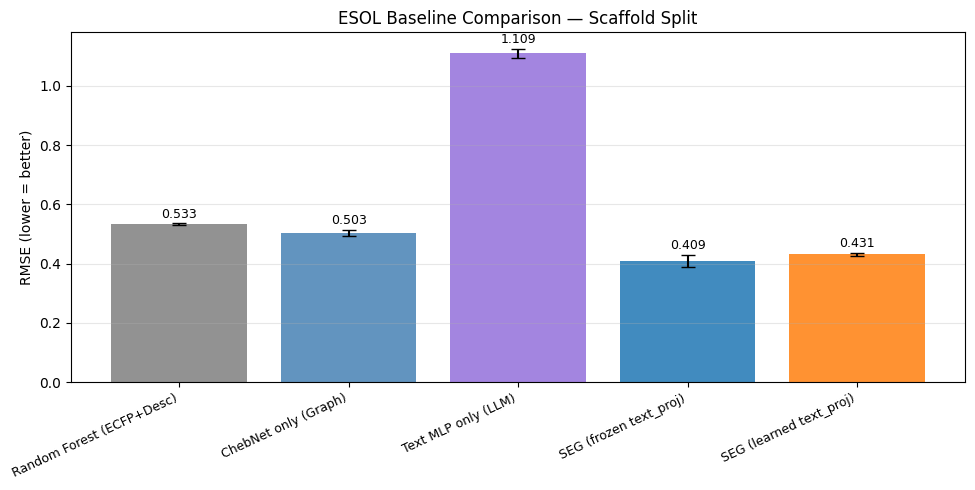

In [ ]:
# === Baseline Comparison: RF, ChebNet, Text-MLP, SEG ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from models.cheb_predictor import ChebPredictor, ChebPredictorConfig

BASELINE_SEEDS = [42, 113, 456, 789]

# --- 1. Features: ECFP (count) + RDKit 2D Descriptors ---
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_features(smiles_list):
    """ECFP count fingerprints + RDKit 2D descriptors."""
    desc_names = [name for name, _ in Descriptors.descList]
    fps, descs = [], []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = morgan_gen.GetCountFingerprint(mol)
            fps.append(np.array([fp[i] for i in range(2048)], dtype=np.float32))
            all_descs = Descriptors.CalcMolDescriptors(mol)
            desc_vals = []
            for name in desc_names:
                try:
                    val = float(all_descs.get(name, 0.0))
                    desc_vals.append(val if np.isfinite(val) else 0.0)
                except (TypeError, ValueError):
                    desc_vals.append(0.0)
            descs.append(desc_vals)
        else:
            fps.append(np.zeros(2048, dtype=np.float32))
            descs.append([0.0] * len(desc_names))
    desc_arr = np.array(descs, dtype=np.float32)
    desc_arr = np.nan_to_num(desc_arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.array(fps), desc_arr

train_fps, train_descs = smiles_to_features(TRAIN_SMILES)
valid_fps, valid_descs = smiles_to_features(VALID_SMILES)
test_fps_arr, test_descs = smiles_to_features(TEST_SMILES)

# Scale descriptors
desc_scaler = StandardScaler()
train_descs_s = desc_scaler.fit_transform(train_descs)
valid_descs_s = desc_scaler.transform(valid_descs)
test_descs_s = desc_scaler.transform(test_descs)

# Combined features
train_X = np.hstack([train_fps, train_descs_s])
valid_X = np.hstack([valid_fps, valid_descs_s])
test_X = np.hstack([test_fps_arr, test_descs_s])
print(f"Features: ECFP={train_fps.shape[1]} + Descriptors={train_descs.shape[1]} = {train_X.shape[1]} total")

# --- 2. Random Forest (ECFP + RDKit Descriptors) ---
rf_results = []
for seed in BASELINE_SEEDS:
    rf = RandomForestRegressor(n_estimators=1000, max_features="sqrt",
                               min_samples_leaf=2, random_state=seed, n_jobs=-1)
    rf.fit(train_X, TRAIN_Y)
    preds = rf.predict(test_X)
    rmse = float(np.sqrt(mean_squared_error(TEST_Y, preds)))
    rf_results.append(rmse)
    print(f"  RF seed={seed}: RMSE={rmse:.4f}")
print(f"  RF Mean RMSE: {np.mean(rf_results):.4f}±{np.std(rf_results):.4f}\n")

# --- 3. ChebNet only (no text) ---
cheb_results = []
for seed in BASELINE_SEEDS:
    set_seed(seed)
    cheb_config = ChebPredictorConfig(
        hidden_channels=64, K=3, num_layers=2, pool="sum",
        dropout=0.3, head_hidden_dim=32, head_dropout=0.5,
    )
    cheb = ChebPredictor(config=cheb_config)
    cheb.fit(
        TRAIN_SMILES, TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES, val_labels=VALID_Y.tolist(),
        num_epochs=200, batch_size=32, learning_rate=5e-4,
        weight_decay=1e-1, patience=30, seed=seed, verbose=False,
    )
    preds = cheb.predict_batch(TEST_SMILES)
    m = regression_metrics(TEST_Y, preds)
    cheb_results.append(m["rmse"])
    print(f"  ChebNet seed={seed}: RMSE={m['rmse']:.4f}")
print(f"  ChebNet Mean RMSE: {np.mean(cheb_results):.4f}±{np.std(cheb_results):.4f}\n")

# --- 4. Text only (MLP on 3072D embeddings) ---
class TextMLP(torch.nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, dropout=0.5):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

text_results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for seed in BASELINE_SEEDS:
    set_seed(seed)
    mlp = TextMLP(input_dim=3072, hidden_dim=128, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(mlp.parameters(), lr=5e-4, weight_decay=1e-1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    train_x = TRAIN_TEXT_EMB.to(device)
    train_y = torch.tensor(TRAIN_Y, device=device)
    val_x = VALID_TEXT_EMB.to(device)
    val_y = torch.tensor(VALID_Y, device=device)
    
    best_val, patience_counter, best_state = float("inf"), 0, None
    for epoch in range(200):
        mlp.train()
        perm = torch.randperm(len(train_x))
        epoch_loss = 0
        for start in range(0, len(train_x), 32):
            idx = perm[start:start+32]
            pred = mlp(train_x[idx])
            loss = torch.nn.functional.mse_loss(pred, train_y[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        mlp.eval()
        with torch.no_grad():
            val_pred = mlp(val_x)
            val_loss = float(torch.sqrt(torch.nn.functional.mse_loss(val_pred, val_y)))
        scheduler.step(val_loss)
        
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in mlp.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 30:
                break
    
    mlp.load_state_dict(best_state)
    mlp.eval()
    with torch.no_grad():
        test_pred = mlp(TEST_TEXT_EMB.to(device)).cpu().numpy()
    m = regression_metrics(TEST_Y, test_pred)
    text_results.append(m["rmse"])
    print(f"  TextMLP seed={seed}: RMSE={m['rmse']:.4f}")
print(f"  TextMLP Mean RMSE: {np.mean(text_results):.4f}±{np.std(text_results):.4f}\n")

# --- 5. SEG frozen & learned (reuse from ALL_RESULTS if available, else train) ---
seg_frozen_results = []
seg_learned_results = []

_has_results = "ALL_RESULTS" in dir() and isinstance(ALL_RESULTS, dict) and \
    "xavier_frozen" in ALL_RESULTS and len(ALL_RESULTS.get("xavier_frozen", {})) >= 4

if _has_results:
    for seed in list(ALL_RESULTS["xavier_frozen"].keys())[:4]:
        seg_frozen_results.append(ALL_RESULTS["xavier_frozen"][seed]["metrics"]["rmse"])
        seg_learned_results.append(ALL_RESULTS["xavier_learned"][seed]["metrics"]["rmse"])
    print("  (Reusing SEG results from main experiments)")
else:
    _seg_base = {
        "hidden_channels": 64, "K": 3, "num_layers": 2, "pool": "sum",
        "fusion": "cross_mha", "fusion_dim": 32, "text_projection_dim": 32,
        "dropout": 0.3, "fusion_dropout": 0.4, "head_dropout": 0.5,
        "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 32,
        "learning_rate": 5e-4, "batch_size": 32, "num_epochs": 200, "patience": 30,
        "scheduler": "plateau", "scheduler_patience": 5, "scheduler_factor": 0.5,
        "min_lr": 1e-6, "grad_clip": None,
    }
    for seed in BASELINE_SEEDS:
        for config_name, freeze in [("frozen", True), ("learned", False)]:
            result = train_and_collect(
                {**_seg_base, "text_proj_init": "xavier", "text_proj_init_gain": 0.1,
                 "freeze_text_proj": freeze}, seed, verbose=False
            )
            rmse = result["metrics"]["rmse"]
            if freeze:
                seg_frozen_results.append(rmse)
            else:
                seg_learned_results.append(rmse)
            print(f"  SEG {config_name} seed={seed}: RMSE={rmse:.4f}")

# === Summary Table ===
print("\n" + "=" * 65)
print("BASELINE COMPARISON — ESOL Scaffold Split")
print("=" * 65)
baselines = {
    "Random Forest (ECFP+Desc)": rf_results,
    "ChebNet only (Graph)": cheb_results,
    "Text MLP only (LLM)":  text_results,
    "SEG (frozen text_proj)": seg_frozen_results,
    "SEG (learned text_proj)": seg_learned_results,
}

print(f"\n{'Model':<28} {'RMSE':>16} {'n':>4}")
print("-" * 52)
for name, results in baselines.items():
    m, s = np.mean(results), np.std(results)
    print(f"  {name:<26} {m:.4f}±{s:.4f}  {len(results):>4}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(baselines.keys())
means = [np.mean(v) for v in baselines.values()]
stds = [np.std(v) for v in baselines.values()]
bar_colors = ["#7f7f7f", "steelblue", "mediumpurple", "tab:blue", "tab:orange"]
bars = ax.bar(range(len(names)), means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("RMSE (lower = better)")
ax.set_title("ESOL Baseline Comparison — Scaffold Split")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.01, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print()

---
## 1. Multi-Seed Training — 4 Configs × 6 Seeds

Configs verglichen:
| Label | `text_proj_init` | `freeze_text_proj` |
|-------|-----------------|-------------------|
| **xavier_frozen** | xavier | True |
| **xavier_learned** | xavier | False |
| **kaiming_frozen** | kaiming | True |
| **kaiming_learned** | kaiming | False |

Alle anderen Hyperparameter: Gewinner aus Grid Search (`hidden_channels=64, K=3, sum pooling`).

In [20]:
# === Train 4 Configs × 6 Seeds ===
SEEDS = [42, 113, 456, 789, 1235, 57]
BASE_CONFIG = {
    "hidden_channels": 64, "K": 3, "num_layers": 2, "pool": "sum",
    "fusion": "cross_mha", "fusion_dim": 32, "text_projection_dim": 32,
    "dropout": 0.3, "fusion_dropout": 0.4, "head_dropout": 0.5,
    "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 32,
    "learning_rate": 5e-4, "batch_size": 32, "num_epochs": 200, "patience": 30,
    "scheduler": "plateau", "scheduler_patience": 5, "scheduler_factor": 0.5,
    "min_lr": 1e-6, "grad_clip": None,
}

CONFIGS = {
    "xavier_frozen":  {**BASE_CONFIG, "text_proj_init": "xavier",  "text_proj_init_gain": 0.1, "freeze_text_proj": True},
    "xavier_learned": {**BASE_CONFIG, "text_proj_init": "xavier",  "text_proj_init_gain": 0.1, "freeze_text_proj": False},
    "kaiming_frozen": {**BASE_CONFIG, "text_proj_init": "kaiming", "text_proj_init_gain": 0.1, "freeze_text_proj": True},
    "kaiming_learned":{**BASE_CONFIG, "text_proj_init": "kaiming", "text_proj_init_gain": 0.1, "freeze_text_proj": False},
}

# Run all experiments
ALL_RESULTS = {}  # {config_name: {seed: result_dict}}

n_total = len(CONFIGS) * len(SEEDS)
counter = 0

for config_name, config in CONFIGS.items():
    ALL_RESULTS[config_name] = {}
    print(f"\n{'='*60}")
    print(f"CONFIG: {config_name}")
    print(f"{'='*60}")
    
    for seed in SEEDS:
        counter += 1
        print(f"  [{counter}/{n_total}] seed={seed}...", end=" ", flush=True)
        result = train_and_collect(config, seed, verbose=False)
        ALL_RESULTS[config_name][seed] = result
        m = result["metrics"]
        print(f"RMSE={m['rmse']:.4f}, MAE={m['mae']:.4f}, R²={m['r2']:.4f}")

print(f"\n✓ All {n_total} experiments complete.")


CONFIG: xavier_frozen
  [1/24] seed=42... RMSE=0.3920, MAE=0.3091, R²=0.8539
  [2/24] seed=113... RMSE=0.3943, MAE=0.3113, R²=0.8522
  [3/24] seed=456... RMSE=0.4084, MAE=0.3302, R²=0.8414
  [4/24] seed=789... RMSE=0.4076, MAE=0.3235, R²=0.8421
  [5/24] seed=1235... RMSE=0.4142, MAE=0.3372, R²=0.8369
  [6/24] seed=57... RMSE=0.4168, MAE=0.3356, R²=0.8348

CONFIG: xavier_learned
  [7/24] seed=42... RMSE=0.4402, MAE=0.3568, R²=0.8158
  [8/24] seed=113... RMSE=0.4334, MAE=0.3536, R²=0.8215
  [9/24] seed=456... RMSE=0.4331, MAE=0.3483, R²=0.8217
  [10/24] seed=789... RMSE=0.4253, MAE=0.3406, R²=0.8280
  [11/24] seed=1235... RMSE=0.4586, MAE=0.3845, R²=0.8000
  [12/24] seed=57... RMSE=0.4306, MAE=0.3501, R²=0.8237

CONFIG: kaiming_frozen
  [13/24] seed=42... RMSE=0.4268, MAE=0.3401, R²=0.8268
  [14/24] seed=113... RMSE=0.4156, MAE=0.3317, R²=0.8358
  [15/24] seed=456... RMSE=0.4193, MAE=0.3272, R²=0.8328
  [16/24] seed=789... RMSE=0.4221, MAE=0.3369, R²=0.8306
  [17/24] seed=1235... RMSE=0

In [21]:
# === Metriken-Übersicht ===
rows = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        rows.append({"config": config_name, "seed": seed, **r["metrics"]})

metrics_df = pd.DataFrame(rows)

# Aggregierte Tabelle
summary = metrics_df.groupby("config").agg(
    rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
    mae_mean=("mae", "mean"), mae_std=("mae", "std"),
    r2_mean=("r2", "mean"), r2_std=("r2", "std"),
    n=("rmse", "count"),
).sort_values("rmse_mean")

print("=== AGGREGATED RESULTS (sorted by RMSE) ===\n")
for config_name, row in summary.iterrows():
    print(f"  {config_name:<20} RMSE={row['rmse_mean']:.4f}±{row['rmse_std']:.4f}  "
          f"MAE={row['mae_mean']:.4f}±{row['mae_std']:.4f}  "
          f"R²={row['r2_mean']:.4f}±{row['r2_std']:.4f}")

summary

=== AGGREGATED RESULTS (sorted by RMSE) ===

  xavier_frozen        RMSE=0.4056±0.0102  MAE=0.3245±0.0121  R²=0.8435±0.0079
  kaiming_learned      RMSE=0.4245±0.0089  MAE=0.3461±0.0080  R²=0.8286±0.0073
  kaiming_frozen       RMSE=0.4252±0.0078  MAE=0.3418±0.0130  R²=0.8281±0.0063
  xavier_learned       RMSE=0.4369±0.0117  MAE=0.3557±0.0151  R²=0.8184±0.0099


,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,n
config,,,,,,,
xavier_frozen,0.405559,0.010231,0.324487,0.012065,0.843548,0.007856,6
kaiming_learned,0.424535,0.008945,0.346116,0.007971,0.828592,0.007271,6
kaiming_frozen,0.425212,0.007819,0.341833,0.012966,0.828060,0.006338,6
xavier_learned,0.436882,0.011692,0.355665,0.015135,0.818435,0.009851,6


---
## 2. Effective Rank Analysis

SVD-basierte Analyse der Repräsentations-Dimensionalität:
- **Graph-Embeddings**: Wie viel Kapazität nutzt der Graph-Encoder tatsächlich?
- **Projizierte Text-Embeddings**: Effektiver Rang der Projektion (frozen vs learned)
- **Fused Embeddings**: Dimensionalität nach Fusion  
- **Projektionsgewichte**: SVD der Gewichtsmatrix W ∈ ℝ^{32×3072} — ist die Projektion low-rank?

Hypothese: Frozen random projection hat einen hohen effektiven Rang (≈ max) → fungiert als Johnson-Lindenstrauss-artige distance-preserving Projektion.  
Learned projection könnte den Rang reduzieren (overfitting auf wenige Dimensionen).

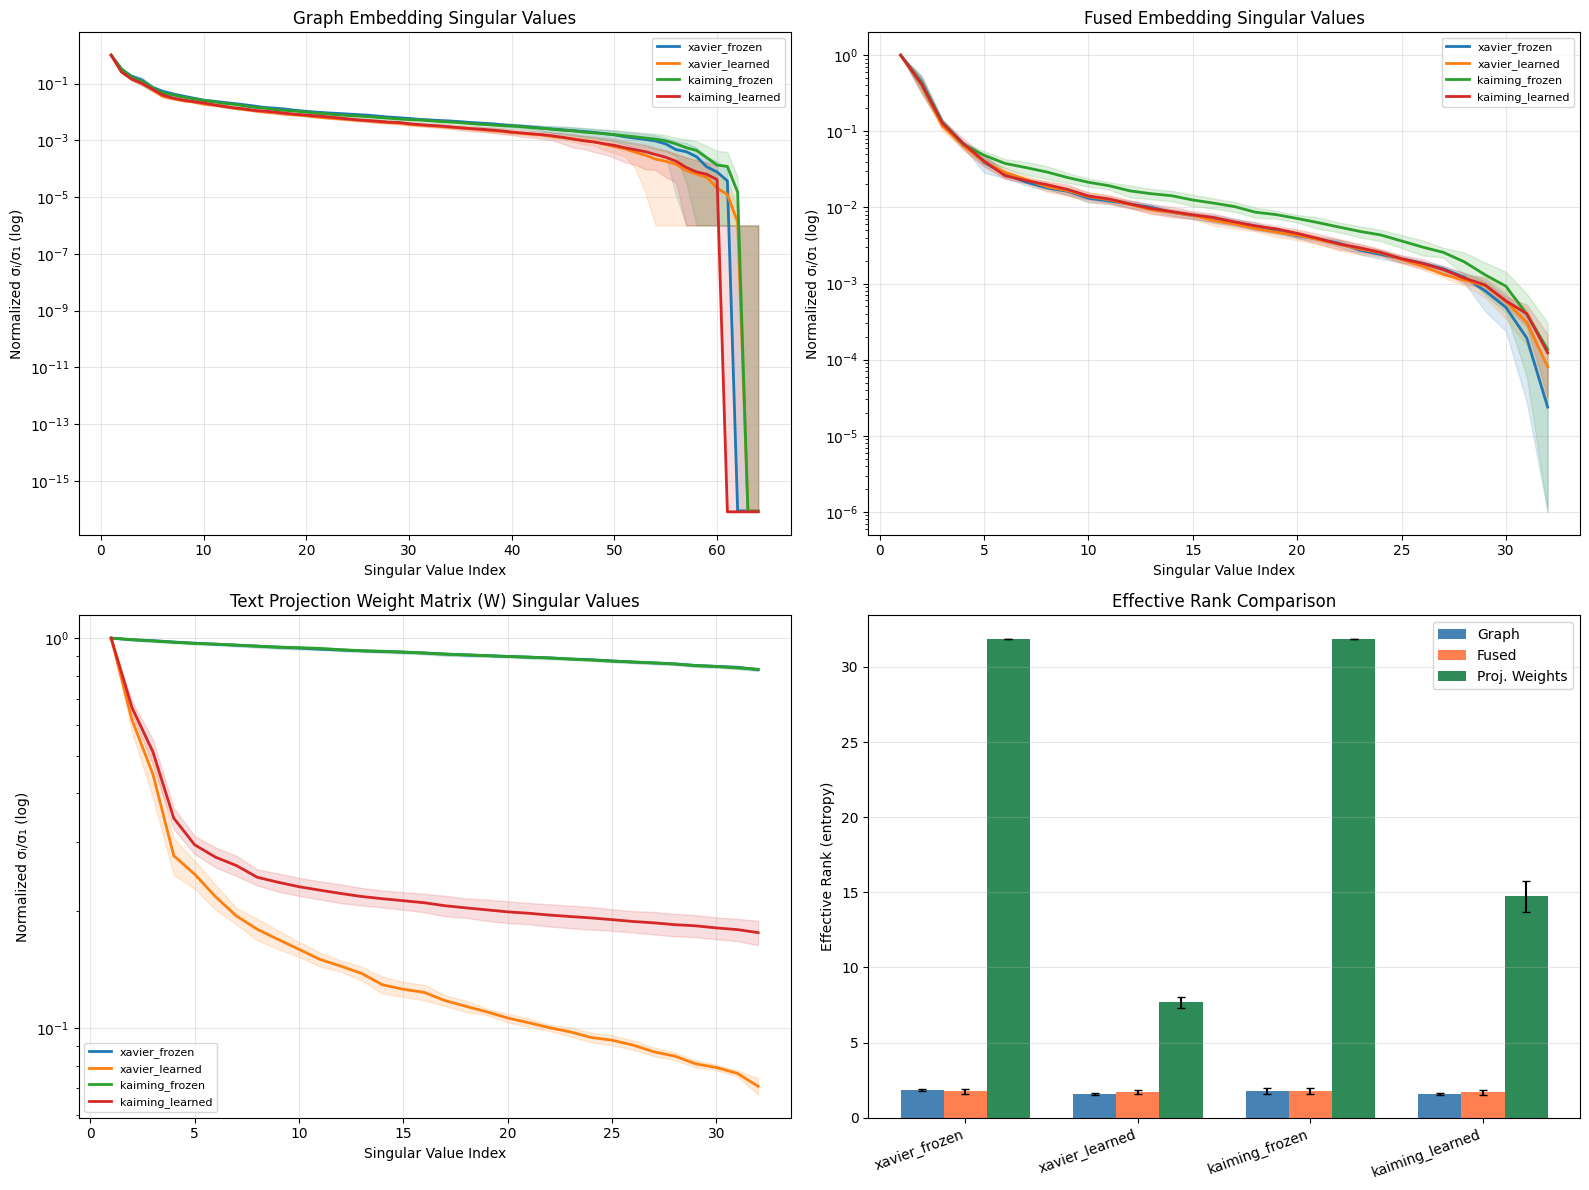


=== EFFECTIVE RANK SUMMARY ===

Config                Graph Eff.Rank  Fused Eff.Rank  Proj.W Eff.Rank
----------------------------------------------------------------------
xavier_frozen            1.8±0.1       1.8±0.2           31.8±0.0
xavier_learned           1.6±0.1       1.7±0.1            7.7±0.4
kaiming_frozen           1.8±0.2       1.8±0.2           31.8±0.0
kaiming_learned          1.6±0.1       1.7±0.2           14.7±1.0

Max possible rank: graph=64, fused=depends on fusion, proj=32


In [22]:
# === Effective Rank: Graph, Text-Proj, Fused ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = {"xavier_frozen": "tab:blue", "xavier_learned": "tab:orange",
          "kaiming_frozen": "tab:green", "kaiming_learned": "tab:red"}

# Collect stats for summary
rank_summary = []

for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        eff_rank_graph = effective_rank(r["S_graph"])
        # Projected text data rank (compute SVD on-the-fly if S_text_proj not stored)
        if "S_text_proj" in r:
            eff_rank_text = effective_rank(r["S_text_proj"])
        else:
            _, S_tp, _ = np.linalg.svd(r["text_proj_emb"], full_matrices=False)
            eff_rank_text = effective_rank(S_tp)
        eff_rank_fused = effective_rank(r["S_fused"])
        eff_rank_proj_w = effective_rank(r["text_proj_weight_S"]) if r["text_proj_weight_S"] is not None else None
        rank_summary.append({
            "config": config_name, "seed": seed,
            "eff_rank_graph": eff_rank_graph, "eff_rank_text": eff_rank_text,
            "eff_rank_fused": eff_rank_fused, "eff_rank_proj_w": eff_rank_proj_w,
        })

# --- Plot 1: Graph Embedding Singular Values ---
ax = axes[0, 0]
for config_name, seed_results in ALL_RESULTS.items():
    all_S = np.array([r["S_graph"] / r["S_graph"][0] for r in seed_results.values()])
    mean_S = all_S.mean(axis=0)
    std_S = all_S.std(axis=0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S, 
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized σᵢ/σ₁ (log)")
ax.set_title("Graph Embedding Singular Values")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 2: Fused Embedding Singular Values ---
ax = axes[0, 1]
for config_name, seed_results in ALL_RESULTS.items():
    all_S = np.array([r["S_fused"] / r["S_fused"][0] for r in seed_results.values()])
    mean_S = all_S.mean(axis=0)
    std_S = all_S.std(axis=0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S, 
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized σᵢ/σ₁ (log)")
ax.set_title("Fused Embedding Singular Values")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 3: Text Projection Weight Singular Values ---
ax = axes[1, 0]
for config_name, seed_results in ALL_RESULTS.items():
    S_arrays = [r["text_proj_weight_S"] for r in seed_results.values() if r["text_proj_weight_S"] is not None]
    if S_arrays:
        all_S = np.array([S / S[0] for S in S_arrays])
        mean_S = all_S.mean(axis=0)
        std_S = all_S.std(axis=0)
        x = np.arange(1, len(mean_S) + 1)
        ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
        ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S, 
                         color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized σᵢ/σ₁ (log)")
ax.set_title("Text Projection Weight Matrix (W) Singular Values")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 4: Effective Rank Summary (bar chart) ---
ax = axes[1, 1]
rank_df = pd.DataFrame(rank_summary)
rank_agg = rank_df.groupby("config").agg(
    graph_mean=("eff_rank_graph", "mean"), graph_std=("eff_rank_graph", "std"),
    fused_mean=("eff_rank_fused", "mean"), fused_std=("eff_rank_fused", "std"),
    proj_w_mean=("eff_rank_proj_w", "mean"), proj_w_std=("eff_rank_proj_w", "std"),
).reindex(["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"])

x = np.arange(len(rank_agg))
width = 0.25
ax.bar(x - width, rank_agg["graph_mean"], width, yerr=rank_agg["graph_std"], 
       label="Graph", color="steelblue", capsize=3)
ax.bar(x, rank_agg["fused_mean"], width, yerr=rank_agg["fused_std"], 
       label="Fused", color="coral", capsize=3)
ax.bar(x + width, rank_agg["proj_w_mean"], width, yerr=rank_agg["proj_w_std"], 
       label="Proj. Weights", color="seagreen", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(rank_agg.index, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Effective Rank Comparison")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Print summary table
print("\n=== EFFECTIVE RANK SUMMARY ===\n")
print(f"{'Config':<20} {'Graph Eff.Rank':>15} {'Fused Eff.Rank':>15} {'Proj.W Eff.Rank':>16}")
print("-" * 70)
for config_name, row in rank_agg.iterrows():
    proj_str = f"{row['proj_w_mean']:.1f}±{row['proj_w_std']:.1f}" if not np.isnan(row['proj_w_mean']) else "N/A"
    print(f"{config_name:<20} {row['graph_mean']:>7.1f}±{row['graph_std']:<5.1f} "
          f"{row['fused_mean']:>7.1f}±{row['fused_std']:<5.1f} "
          f"{proj_str:>16}")
print()
print(f"Max possible rank: graph={BASE_CONFIG['hidden_channels']}, "
      f"fused=depends on fusion, proj={BASE_CONFIG['text_projection_dim']}")

### 2b. Johnson-Lindenstrauss Distance Preservation Test

**Der eigentliche JL-Test:** Bleiben paarweise Distanzen bei der Projektion 3072D → 32D erhalten?

Wir messen die Spearman-Korrelation zwischen:
- L2-Distanzen im **Original** text-embedding-Raum (3072D)  
- L2-Distanzen im **projizierten** Raum (32D)

Erwartung: Frozen random projection sollte Distanzen ≈ proportional erhalten (JL-Garantie).
Learned projection *könnte* Distanzen verzerren (task-spezifisches Kollabieren naher Punkte).

**Zusätzlich:** Trainable-Parameter-Vergleich, um die einfachste Erklärung zu prüfen.

Original text embeddings: (113, 3072)
Pairwise distances computed: 6328 pairs



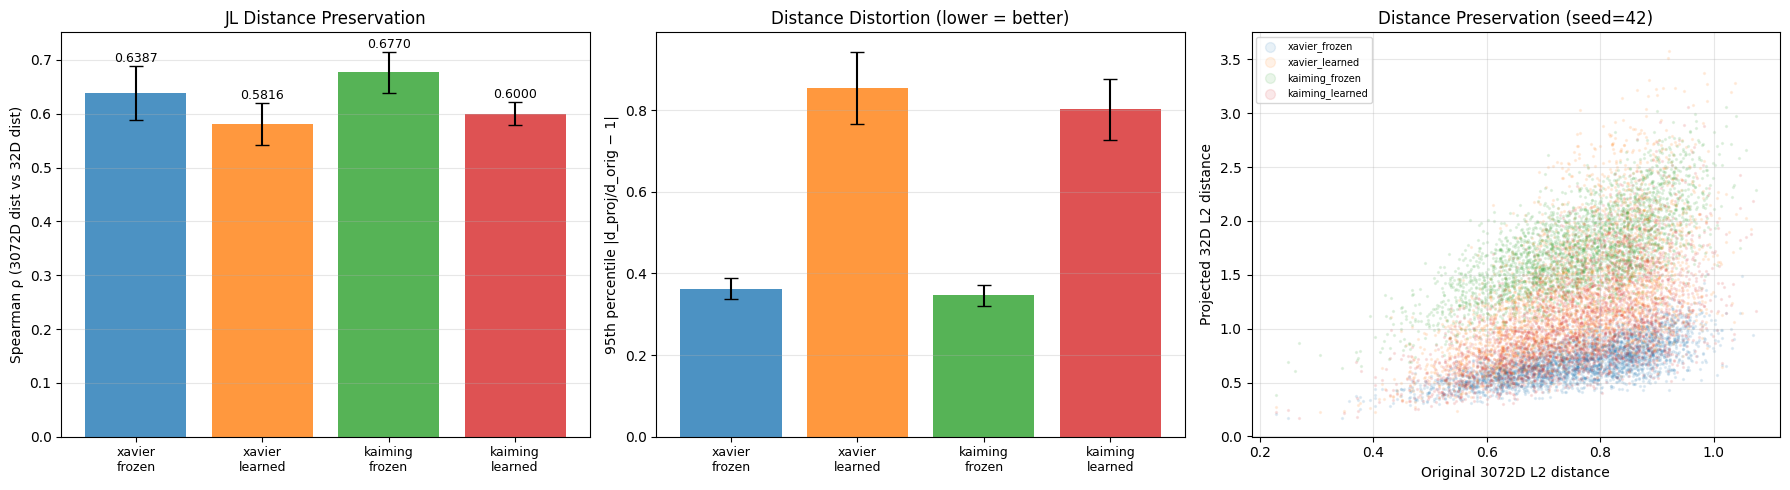


=== TRAINABLE PARAMETER COUNT ===

  xavier_frozen        total= 132,129  trainable=  33,729  frozen=  98,400  (26% trainable)
  xavier_learned       total= 132,129  trainable= 132,129  frozen=       0  (100% trainable)
  kaiming_frozen       total= 132,129  trainable=  33,729  frozen=  98,400  (26% trainable)
  kaiming_learned      total= 132,129  trainable= 132,129  frozen=       0  (100% trainable)

=== JL DISTANCE PRESERVATION SUMMARY ===

Config                   Spearman ρ   95% Distortion
-------------------------------------------------------
  xavier_frozen        0.6387±0.0501   0.363±0.025
  xavier_learned       0.5816±0.0391   0.855±0.088
  kaiming_frozen       0.6770±0.0385   0.346±0.025
  kaiming_learned      0.6000±0.0213   0.801±0.075


In [23]:
# === JL Distance Preservation + Parameter Count ===
from scipy.stats import spearmanr

# --- 1. Pairwise L2 distances in original 3072D text embedding space ---
text_emb_np = TEST_TEXT_EMB.numpy()
dist_original = pdist(text_emb_np, metric="euclidean")  # condensed (n*(n-1)/2,)
print(f"Original text embeddings: {text_emb_np.shape}")
print(f"Pairwise distances computed: {len(dist_original)} pairs\n")

# --- 2. Compare with projected distances for each config/seed ---
jl_results = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        proj_emb = r["text_proj_emb"]  # (n_test, 32)
        dist_proj = pdist(proj_emb, metric="euclidean")
        
        rho, pval = spearmanr(dist_original, dist_proj)
        
        # Also compute relative distortion: max(|d_proj/d_orig - c|) for optimal c
        # (JL guarantees (1-eps)*d <= d_proj <= (1+eps)*d)
        ratio = dist_proj / (dist_original + 1e-10)
        median_ratio = np.median(ratio)
        normalized = ratio / median_ratio  # center around 1
        max_distortion = np.max(np.abs(normalized - 1.0))
        p95_distortion = np.percentile(np.abs(normalized - 1.0), 95)
        
        jl_results.append({
            "config": config_name, "seed": seed,
            "spearman_rho": rho, "p_value": pval,
            "max_distortion": max_distortion, "p95_distortion": p95_distortion,
            "median_ratio": median_ratio,
        })

jl_df = pd.DataFrame(jl_results)

# --- Plot 1: Spearman rho bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]

ax = axes[0]
means, stds = [], []
for c in config_order:
    vals = jl_df[jl_df["config"] == c]["spearman_rho"]
    means.append(vals.mean()); stds.append(vals.std())
bars = ax.bar(range(len(config_order)), means, yerr=stds, capsize=5,
              color=["tab:blue", "tab:orange", "tab:green", "tab:red"], alpha=0.8)
ax.set_xticks(range(len(config_order)))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("Spearman ρ (3072D dist vs 32D dist)")
ax.set_title("JL Distance Preservation")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.002, f"{m:.4f}", ha="center", va="bottom", fontsize=9)

# --- Plot 2: 95th percentile distortion ---
ax = axes[1]
means, stds = [], []
for c in config_order:
    vals = jl_df[jl_df["config"] == c]["p95_distortion"]
    means.append(vals.mean()); stds.append(vals.std())
ax.bar(range(len(config_order)), means, yerr=stds, capsize=5,
       color=["tab:blue", "tab:orange", "tab:green", "tab:red"], alpha=0.8)
ax.set_xticks(range(len(config_order)))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("95th percentile |d_proj/d_orig − 1|")
ax.set_title("Distance Distortion (lower = better)")
ax.grid(alpha=0.3, axis="y")

# --- Plot 3: Scatter for one seed per config ---
ax = axes[2]
seed0 = min(ALL_RESULTS["xavier_frozen"].keys())
for config_name in config_order:
    r = ALL_RESULTS[config_name][seed0]
    proj_emb = r["text_proj_emb"]
    dist_proj = pdist(proj_emb, metric="euclidean")
    # Subsample
    n_pairs = len(dist_original)
    idx_sub = np.random.choice(n_pairs, min(3000, n_pairs), replace=False)
    ax.scatter(dist_original[idx_sub], dist_proj[idx_sub], alpha=0.1, s=2, 
               label=config_name, rasterized=True)
ax.set_xlabel("Original 3072D L2 distance")
ax.set_ylabel("Projected 32D L2 distance")
ax.set_title(f"Distance Preservation (seed={seed0})")
ax.legend(fontsize=7, markerscale=5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Trainable Parameter Count ---
# NOTE: SEGPredictor freezes text_proj by EXCLUDING it from the optimizer
# (see _get_parameters()), not by setting requires_grad=False.
# So we check model.config.freeze_text_proj instead.
print("\n=== TRAINABLE PARAMETER COUNT ===\n")
seed0 = min(ALL_RESULTS["xavier_frozen"].keys())
for config_name in config_order:
    model = ALL_RESULTS[config_name][seed0]["model"]
    total = sum(p.numel() for p in model._encoder.parameters())
    total += sum(p.numel() for p in model._pooling.parameters())
    total += sum(p.numel() for p in model._fusion.parameters())
    total += sum(p.numel() for p in model._head.parameters())
    text_proj_params = 0
    if model._text_proj:
        text_proj_params = sum(p.numel() for p in model._text_proj.parameters())
        total += text_proj_params
    frozen_p = text_proj_params if model.config.freeze_text_proj else 0
    trainable = total - frozen_p
    print(f"  {config_name:<20} total={total:>8,}  trainable={trainable:>8,}  frozen={frozen_p:>8,}  "
          f"({100*trainable/total:.0f}% trainable)")

# --- JL Summary ---
print("\n=== JL DISTANCE PRESERVATION SUMMARY ===\n")
jl_summary = jl_df.groupby("config").agg(
    rho_mean=("spearman_rho", "mean"), rho_std=("spearman_rho", "std"),
    dist95_mean=("p95_distortion", "mean"), dist95_std=("p95_distortion", "std"),
).reindex(config_order)

print(f"{'Config':<20} {'Spearman ρ':>14} {'95% Distortion':>16}")
print("-" * 55)
for c, row in jl_summary.iterrows():
    print(f"  {c:<20} {row['rho_mean']:.4f}±{row['rho_std']:.4f}   {row['dist95_mean']:.3f}±{row['dist95_std']:.3f}")

## 3. Embedding Stability Across Seeds

**Key Question:** Does freezing the text projection lead to more reproducible
learned representations?

We measure stability via **CKA** (Centered Kernel Alignment, Kornblith 2019)
for three embedding types: Graph, Text-Projected, and Fused.

⚠ **Wichtiger Caveat:** Bei **frozen** text\_proj hat jeder Seed eine *andere*
zufällige Projektion (set\_seed vor Model-Init). TextProj-CKA für frozen wird
also per Design niedrig sein — das sagt nichts über Qualität, sondern nur,
dass verschiedene Random-Matrizen verschiedene Projektionen erzeugen.  
→ Die interessante Frage: Konvergiert der **Graph-Encoder** trotzdem stabil?

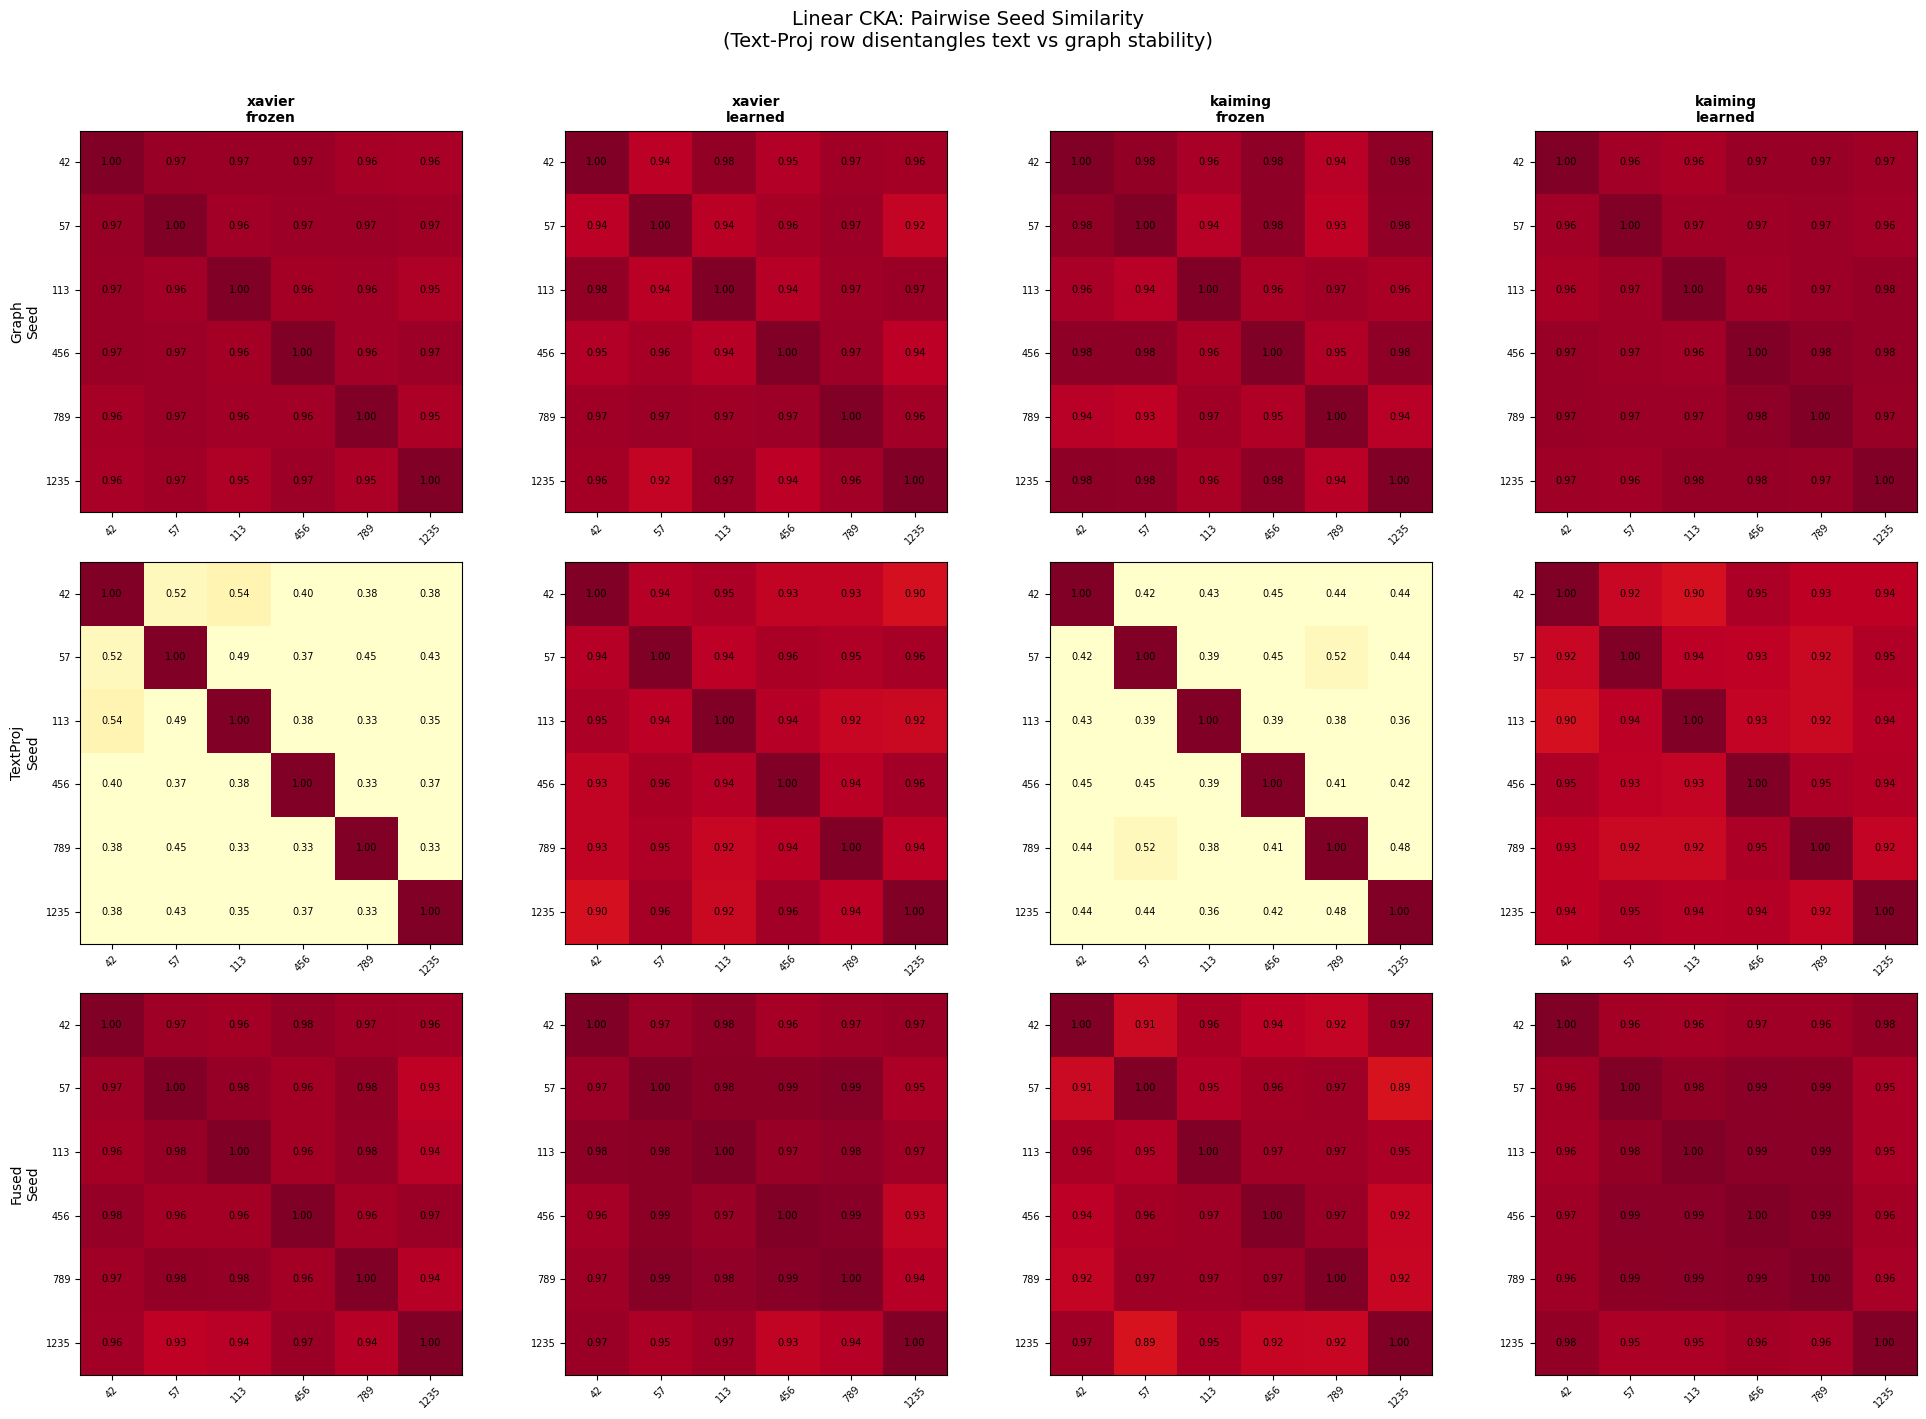


=== CKA SUMMARY (off-diagonal mean ± std) ===

Config                  Graph CKA   TextProj CKA    Fused CKA
-----------------------------------------------------------------
xavier_frozen         0.964±0.007    0.402±0.067    0.963±0.014  
xavier_learned        0.956±0.016    0.938±0.017    0.970±0.017  
kaiming_frozen        0.962±0.018    0.429±0.039    0.945±0.023  
kaiming_learned       0.970±0.006    0.932±0.015    0.972±0.013  

⚠ CAVEAT: Frozen text_proj uses different random weights per seed!
  → Low TextProj CKA for frozen = expected (different random projections)
  → Key insight: Does the Graph encoder compensate for this variability?


In [24]:
# === Embedding Stability: CKA + per-molecule variance ===
from scipy.spatial.distance import pdist, squareform

def linear_CKA(X, Y):
    """Linear CKA between two embedding matrices (n_samples × dim).
    Kornblith et al. 2019."""
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    hsic_xy = np.linalg.norm(X.T @ Y, 'fro')**2
    hsic_xx = np.linalg.norm(X.T @ X, 'fro')**2
    hsic_yy = np.linalg.norm(Y.T @ Y, 'fro')**2
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)

# Compute pairwise CKA for each config × embedding type
# Include text_proj_emb to disentangle graph vs. text stability!
cka_results = {}
for config_name, seed_results in ALL_RESULTS.items():
    seeds = sorted(seed_results.keys())
    n = len(seeds)
    
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        emb_list = [seed_results[s][emb_type] for s in seeds]
        cka_matrix = np.ones((n, n))
        for i in range(n):
            for j in range(i+1, n):
                c = linear_CKA(emb_list[i], emb_list[j])
                cka_matrix[i, j] = c
                cka_matrix[j, i] = c
        cka_results[(config_name, emb_type)] = cka_matrix

# --- Plot CKA heatmaps: 3 rows (Graph, Text-Proj, Fused) × 4 cols ---
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
config_names = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]

for col, config_name in enumerate(config_names):
    for row, (emb_type, emb_label) in enumerate([
        ("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")
    ]):
        ax = axes[row, col]
        cka = cka_results[(config_name, emb_type)]
        seeds = sorted(ALL_RESULTS[config_name].keys())
        im = ax.imshow(cka, vmin=0.5, vmax=1.0, cmap="YlOrRd")
        ax.set_xticks(range(len(seeds)))
        ax.set_xticklabels(seeds, fontsize=7, rotation=45)
        ax.set_yticks(range(len(seeds)))
        ax.set_yticklabels(seeds, fontsize=7)
        
        # Annotate values
        for i in range(len(seeds)):
            for j in range(len(seeds)):
                ax.text(j, i, f"{cka[i,j]:.2f}", ha="center", va="center", fontsize=7)
        
        if row == 0:
            ax.set_title(config_name.replace("_", "\n"), fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{emb_label}\nSeed", fontsize=10)

fig.suptitle("Linear CKA: Pairwise Seed Similarity\n(Text-Proj row disentangles text vs graph stability)", 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary statistics ---
print("\n=== CKA SUMMARY (off-diagonal mean ± std) ===\n")
print(f"{'Config':<20} {'Graph CKA':>12} {'TextProj CKA':>14} {'Fused CKA':>12}")
print("-" * 65)
for config_name in config_names:
    row_str = f"{config_name:<20}"
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        cka = cka_results[(config_name, emb_type)]
        off_diag = cka[np.triu_indices_from(cka, k=1)]
        row_str += f"  {off_diag.mean():.3f}±{off_diag.std():.3f}  "
    print(row_str)

print("\n⚠ CAVEAT: Frozen text_proj uses different random weights per seed!")
print("  → Low TextProj CKA for frozen = expected (different random projections)")
print("  → Key insight: Does the Graph encoder compensate for this variability?")

## 4. Tanimoto & |Δy| vs. Embedding Distance Correlation

Zwei Korrelationen, die Verschiedenes messen:

1. **Tanimoto ↔ Embedding Cosine Similarity** (strukturelle Ähnlichkeit)
   - Nutzt Morgan-Fingerprints (radius=2, 2048 bits)
   - Misst, ob der Embedding-Raum molekulare Substruktur-Ähnlichkeit widerspiegelt
   - ⚠ Hohe Korrelation heißt NICHT automatisch besseres Modell

2. **|Δy| ↔ Embedding L2-Distanz** (task-relevante Ähnlichkeit)
   - Korreliert die absolute Eigenschaftsdifferenz mit der Embedding-Distanz
   - Misst, ob ähnliche Vorhersage-Targets nahe beieinander im Embedding liegen
   - ← **Das ist die eigentlich relevante Metrik!**

Test set: 113 molecules, 6328 pairs


[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerator
[17:03:45] DEPRECATION WARNING: please use MorganGenerat

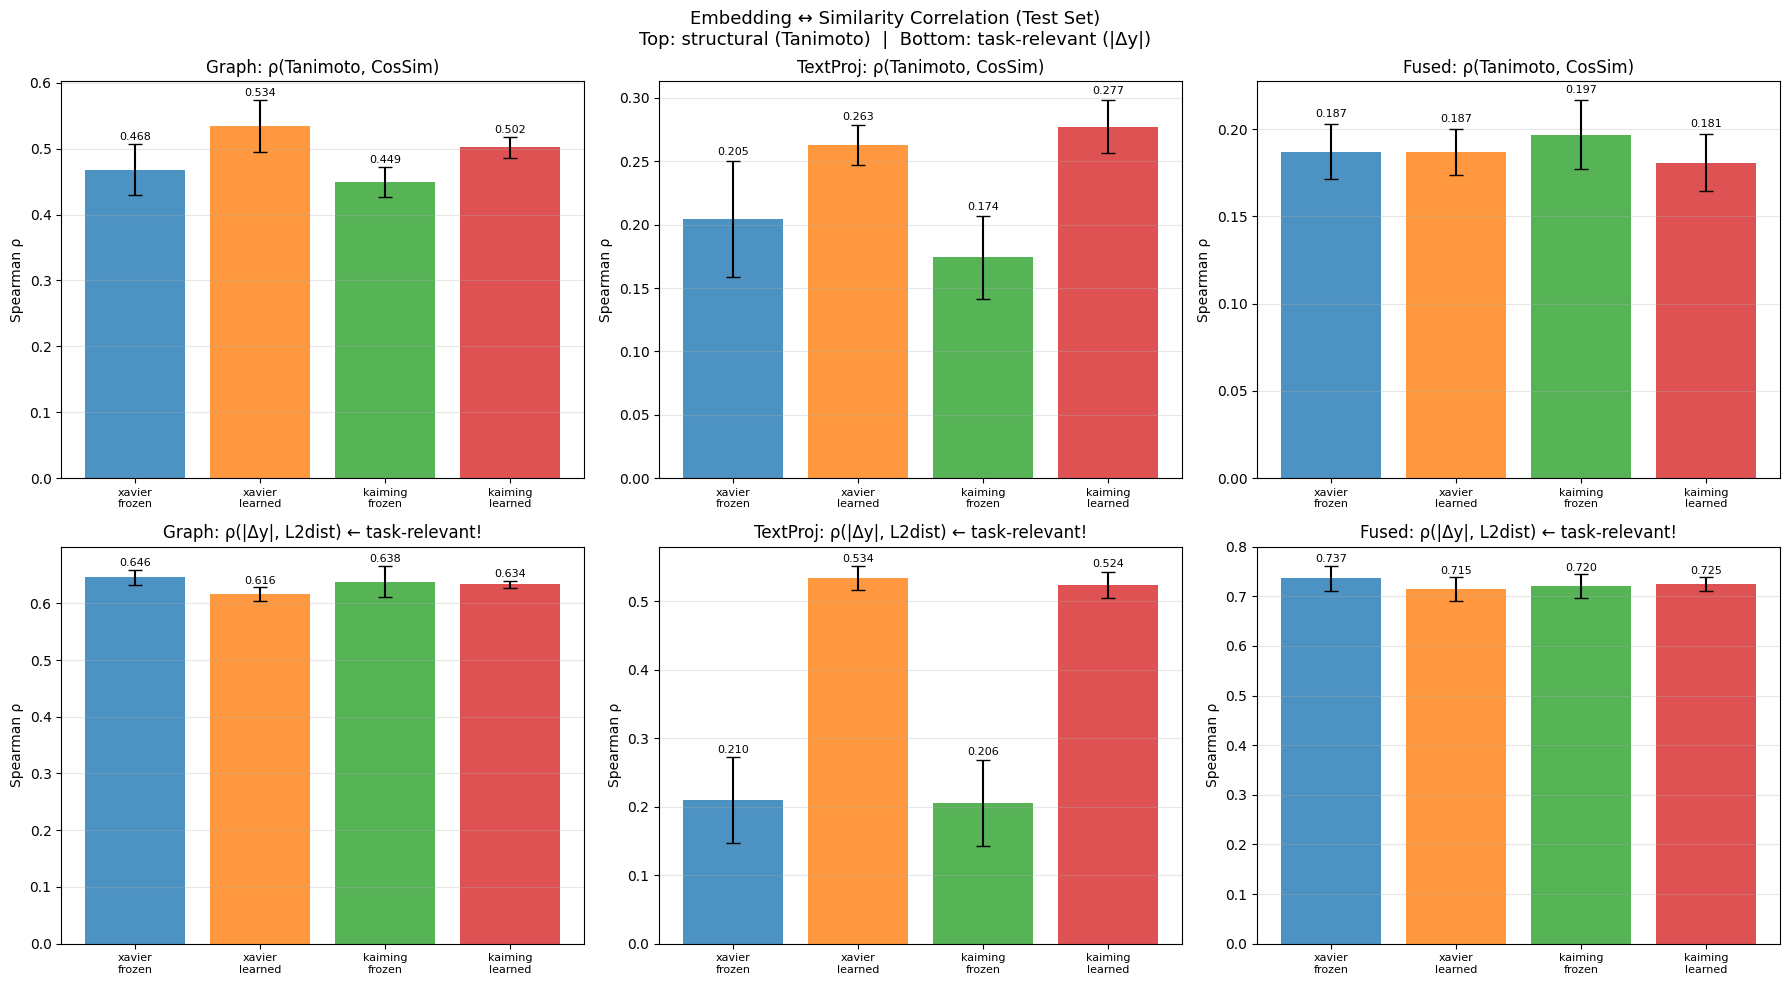

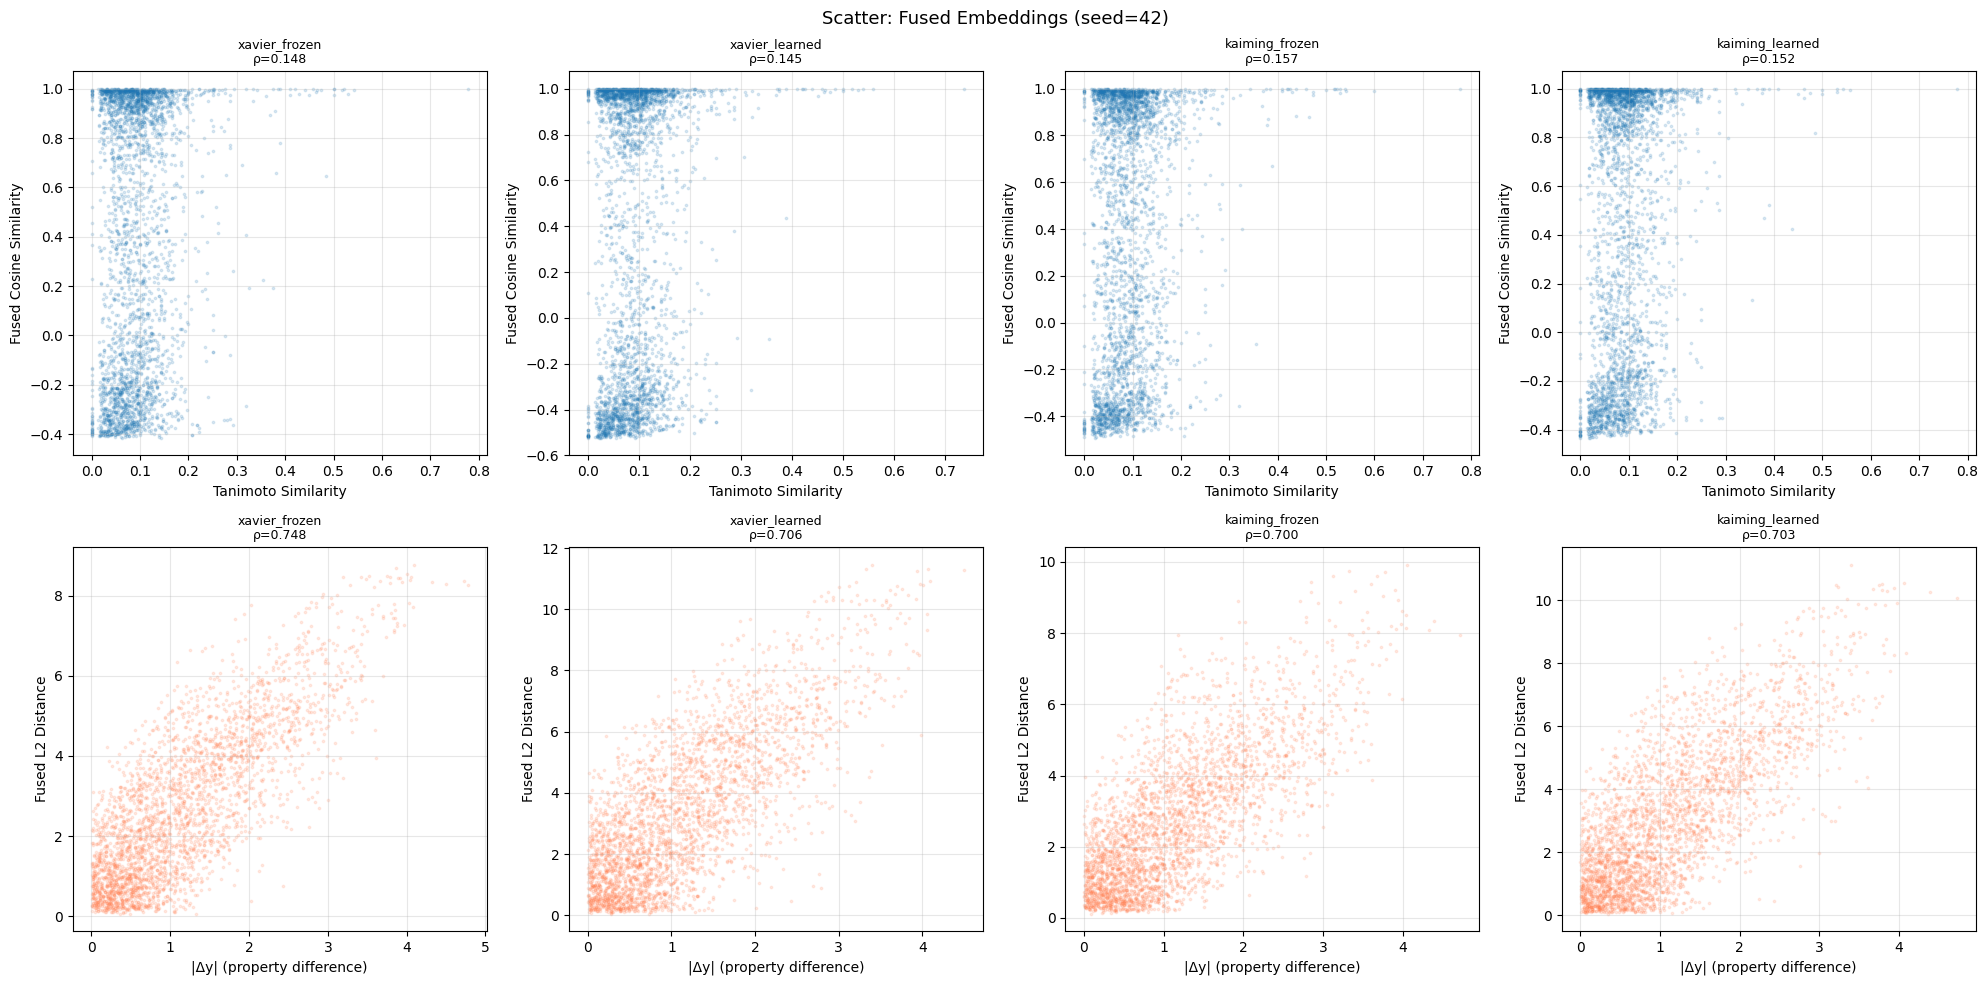


=== CORRELATION SUMMARY ===

--- Tanimoto Correlation ---
                   mean                      std                 
embedding         Fused   Graph TextProj   Fused   Graph TextProj
config                                                           
kaiming_frozen   0.1968  0.4495   0.1743  0.0198  0.0230   0.0326
kaiming_learned  0.1808  0.5023   0.2774  0.0162  0.0155   0.0210
xavier_frozen    0.1871  0.4683   0.2048  0.0156  0.0386   0.0458
xavier_learned   0.1869  0.5344   0.2628  0.0133  0.0396   0.0156

--- |Δy| Correlation ---
                   mean                      std                 
embedding         Fused   Graph TextProj   Fused   Graph TextProj
config                                                           
kaiming_frozen   0.7203  0.6383   0.2061  0.0245  0.0281   0.0629
kaiming_learned  0.7245  0.6337   0.5243  0.0139  0.0061   0.0192
xavier_frozen    0.7366  0.6460   0.2096  0.0254  0.0134   0.0631
xavier_learned   0.7149  0.6161   0.5343  0.0234  0.0120 

In [25]:
# === Tanimoto & |Δy| ↔ Embedding Distance Correlation ===
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from scipy.stats import spearmanr

# --- Compute Tanimoto similarity (condensed) on test set ---
test_mols = [Chem.MolFromSmiles(s) for s in TEST_SMILES]
test_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in test_mols if m is not None]
n_test = len(test_fps)

# Compute condensed Tanimoto similarity directly (avoids squareform diagonal issue)
tanimoto_sim = []
for i in range(n_test):
    for j in range(i + 1, n_test):
        tanimoto_sim.append(DataStructs.TanimotoSimilarity(test_fps[i], test_fps[j]))
tanimoto_sim = np.array(tanimoto_sim)

# --- Compute |Δy| (property difference) — the task-relevant reference ---
delta_y = pdist(TEST_Y.reshape(-1, 1), metric="euclidean")  # = |y_i - y_j|

print(f"Test set: {n_test} molecules, {len(tanimoto_sim)} pairs")

# --- Compute cosine similarity for each config/seed/embedding type ---
# Include text_proj_emb to see if projection preserves structure
corr_results = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        for emb_key, emb_label in [("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")]:
            emb = r[emb_key]
            if len(emb) != n_test:
                continue
            cos_dist = pdist(emb, metric="cosine")
            cos_sim = 1.0 - cos_dist
            emb_l2 = pdist(emb, metric="euclidean")
            
            # Tanimoto correlation (structural similarity)
            rho_tan, _ = spearmanr(tanimoto_sim, cos_sim)
            # |Δy| correlation (task-relevant: does embedding distance predict property diff?)
            rho_dy, _ = spearmanr(delta_y, emb_l2)
            
            corr_results.append({
                "config": config_name, "seed": seed, "embedding": emb_label,
                "rho_tanimoto": rho_tan, "rho_delta_y": rho_dy,
            })

corr_df = pd.DataFrame(corr_results)
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]

# --- Plot 1: Bar charts — Tanimoto ρ and |Δy| ρ side by side ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
emb_labels = ["Graph", "TextProj", "Fused"]

for col, emb_label in enumerate(emb_labels):
    sub = corr_df[corr_df["embedding"] == emb_label]
    
    # Row 0: Tanimoto correlation
    ax = axes[0, col]
    means = [sub[sub["config"] == c]["rho_tanimoto"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_tanimoto"].std() for c in config_order]
    ax.bar(range(4), means, yerr=stds, capsize=5,
           color=["tab:blue", "tab:orange", "tab:green", "tab:red"], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"{emb_label}: ρ(Tanimoto, CosSim)")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    
    # Row 1: |Δy| correlation (TASK-RELEVANT)
    ax = axes[1, col]
    means = [sub[sub["config"] == c]["rho_delta_y"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_delta_y"].std() for c in config_order]
    ax.bar(range(4), means, yerr=stds, capsize=5,
           color=["tab:blue", "tab:orange", "tab:green", "tab:red"], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"{emb_label}: ρ(|Δy|, L2dist) ← task-relevant!")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Embedding ↔ Similarity Correlation (Test Set)\n"
             "Top: structural (Tanimoto)  |  Bottom: task-relevant (|Δy|)", fontsize=13)
plt.tight_layout()
plt.show()

# --- Plot 2: Scatter examples for first seed ---
seed0 = min(ALL_RESULTS["xavier_frozen"].keys())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for col, config_name in enumerate(config_order):
    r = ALL_RESULTS[config_name][seed0]
    
    fused_emb = r["fused_emb"]
    fused_l2 = pdist(fused_emb, metric="euclidean")
    n_pairs = len(tanimoto_sim)
    idx_sub = np.random.choice(n_pairs, min(3000, n_pairs), replace=False)
    
    # Row 0: Tanimoto vs fused cosine sim
    ax = axes[0, col]
    cos_sim = 1.0 - pdist(fused_emb, metric="cosine")
    ax.scatter(tanimoto_sim[idx_sub], cos_sim[idx_sub], alpha=0.15, s=3, rasterized=True)
    rho, _ = spearmanr(tanimoto_sim[idx_sub], cos_sim[idx_sub])
    ax.set_xlabel("Tanimoto Similarity")
    ax.set_ylabel("Fused Cosine Similarity")
    ax.set_title(f"{config_name}\nρ={rho:.3f}", fontsize=9)
    ax.grid(alpha=0.3)
    
    # Row 1: |Δy| vs fused L2 distance
    ax = axes[1, col]
    ax.scatter(delta_y[idx_sub], fused_l2[idx_sub], alpha=0.15, s=3, c="coral", rasterized=True)
    rho, _ = spearmanr(delta_y[idx_sub], fused_l2[idx_sub])
    ax.set_xlabel("|Δy| (property difference)")
    ax.set_ylabel("Fused L2 Distance")
    ax.set_title(f"{config_name}\nρ={rho:.3f}", fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Scatter: Fused Embeddings (seed={seed0})", fontsize=13)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n=== CORRELATION SUMMARY ===\n")
for metric_col, metric_name in [("rho_tanimoto", "Tanimoto"), ("rho_delta_y", "|Δy|")]:
    print(f"--- {metric_name} Correlation ---")
    pivot = corr_df.groupby(["config", "embedding"])[metric_col].agg(["mean", "std"])
    pivot = pivot.unstack()
    print(pivot.round(4))
    print()

## 5. Learning Curves: Frozen vs Learned

**Hypothesis:** Learning the text projection introduces extra capacity that
leads to overfitting on the small ESOL training set (902 samples).

We re-train with epoch-level loss tracking and plot:
- Train vs. Validation loss curves (generalization gap)
- Comparison across frozen/learned configs

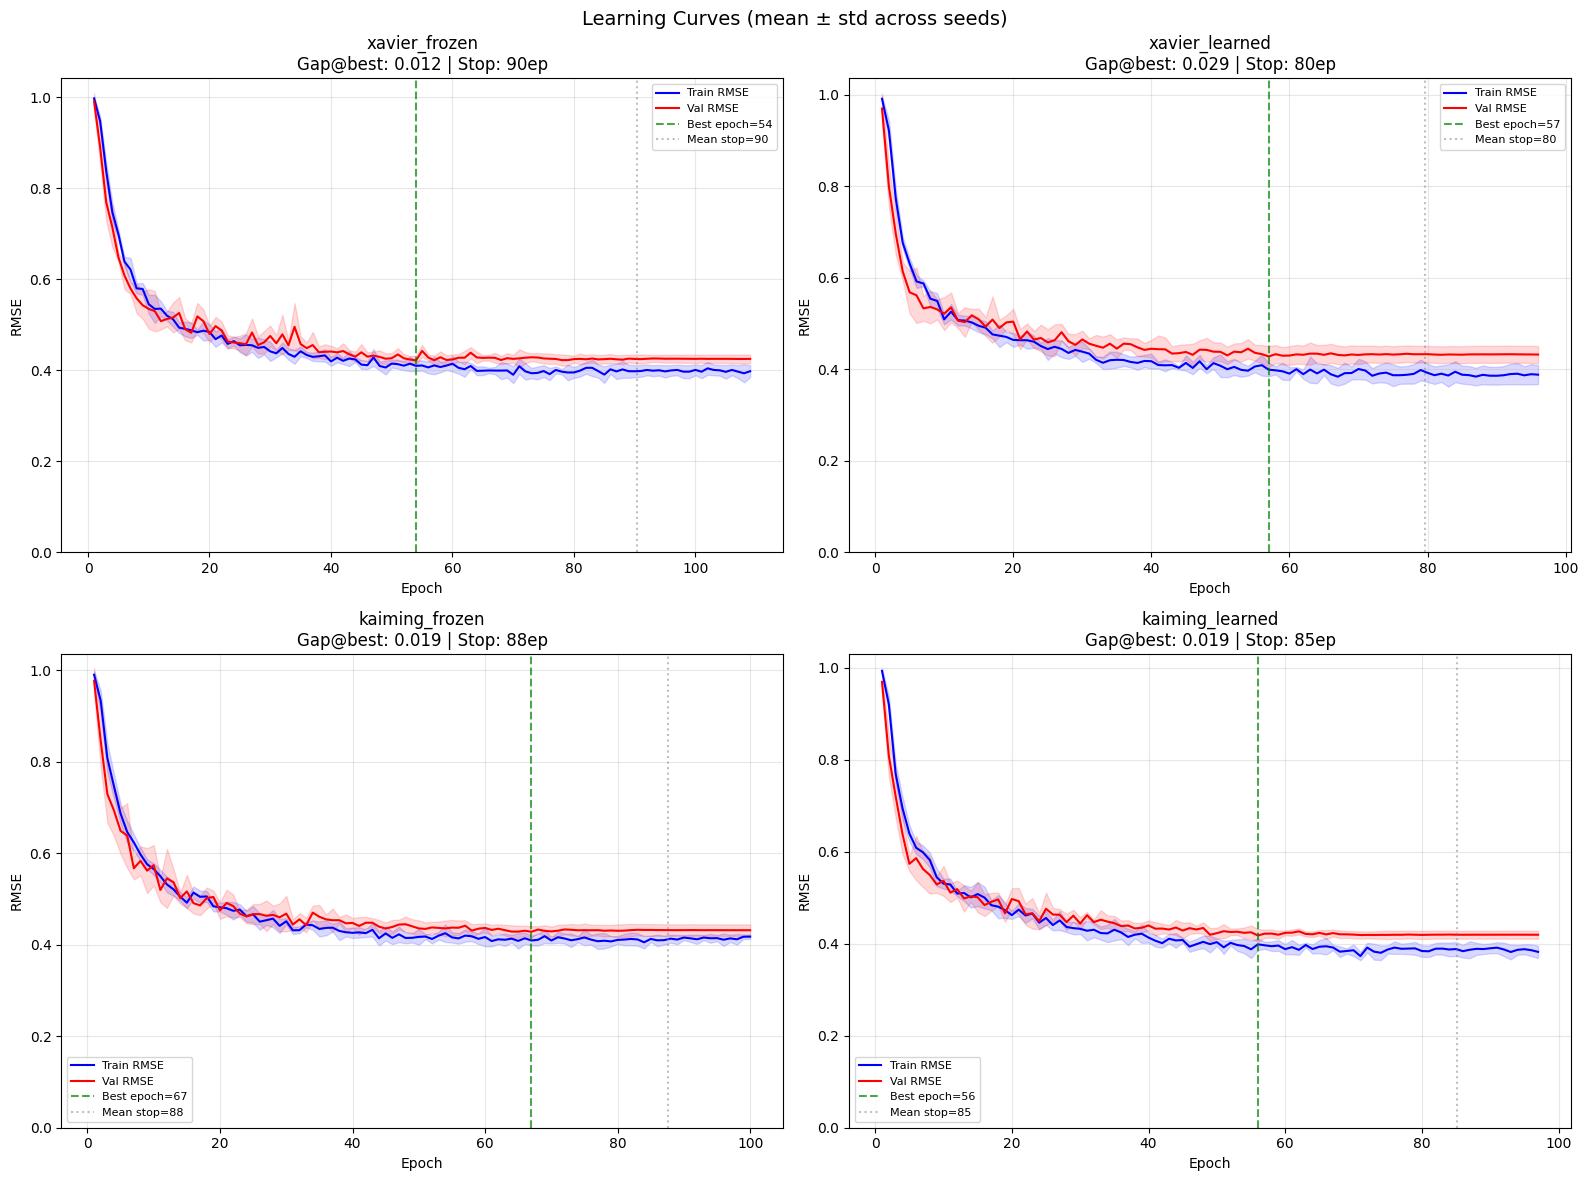


=== GENERALIZATION GAP SUMMARY ===

Config                Best Val RMSE   Train@Best   Gap@Best   Epochs     Stop
--------------------------------------------------------------------------------
xavier_frozen         0.4122±0.0094  0.4043±0.0159      0.008       90      109
xavier_learned        0.4224±0.0200  0.4015±0.0129      0.021       80       96
kaiming_frozen        0.4239±0.0135  0.4187±0.0060      0.005       88      100
kaiming_learned       0.4100±0.0103  0.4046±0.0091      0.005       85       97


In [26]:
# === Learning Curves: Frozen vs Learned ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]

for idx, config_name in enumerate(config_order):
    ax = axes[idx // 2, idx % 2]
    seed_results = ALL_RESULTS[config_name]
    
    # Collect train/val losses across seeds
    all_train = []
    all_val = []
    for seed, r in seed_results.items():
        h = r["history"]
        all_train.append(h["train_loss"])
        # val_metric is RMSE (sqrt of val_loss for regression)
        all_val.append(h["val_metric"])
    
    # Pad to same length (early stopping may stop at different epochs)
    max_len = max(len(t) for t in all_train)
    
    for i in range(len(all_train)):
        last_train = all_train[i][-1]
        last_val = all_val[i][-1]
        all_train[i] = all_train[i] + [last_train] * (max_len - len(all_train[i]))
        all_val[i] = all_val[i] + [last_val] * (max_len - len(all_val[i]))
    
    all_train = np.array(all_train)
    all_val = np.array(all_val)
    
    epochs = np.arange(1, max_len + 1)
    
    # Compute sqrt for train to make it RMSE too
    all_train_rmse = np.sqrt(all_train)
    
    # Plot mean ± std
    ax.plot(epochs, all_train_rmse.mean(0), 'b-', linewidth=1.5, label="Train RMSE")
    ax.fill_between(epochs, all_train_rmse.mean(0) - all_train_rmse.std(0), 
                    all_train_rmse.mean(0) + all_train_rmse.std(0), alpha=0.15, color="blue")
    
    ax.plot(epochs, all_val.mean(0), 'r-', linewidth=1.5, label="Val RMSE")
    ax.fill_between(epochs, all_val.mean(0) - all_val.std(0), 
                    all_val.mean(0) + all_val.std(0), alpha=0.15, color="red")
    
    # Generalization gap
    gap = all_val.mean(0) - all_train_rmse.mean(0)
    
    # Mark best epoch (lowest val RMSE) and actual stop epochs
    best_epoch_idx = np.argmin(all_val.mean(0))
    actual_lengths = [len(r["history"]["train_loss"]) for r in seed_results.values()]
    mean_stop = np.mean(actual_lengths)
    gap_at_best = gap[best_epoch_idx]
    
    ax.axvline(best_epoch_idx + 1, color="green", linestyle="--", alpha=0.7, label=f"Best epoch={best_epoch_idx+1}")
    ax.axvline(mean_stop, color="gray", linestyle=":", alpha=0.5, label=f"Mean stop={mean_stop:.0f}")
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title(f"{config_name}\nGap@best: {gap_at_best:.3f} | Stop: {mean_stop:.0f}ep")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle("Learning Curves (mean ± std across seeds)", fontsize=14)
plt.tight_layout()
plt.show()

# --- Generalization Gap Summary (at BEST epoch, not final) ---
print("\n=== GENERALIZATION GAP SUMMARY ===\n")
print(f"{'Config':<20} {'Best Val RMSE':>14} {'Train@Best':>12} {'Gap@Best':>10} {'Epochs':>8} {'Stop':>8}")
print("-" * 80)
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    
    best_val_per_seed = []
    train_at_best_per_seed = []
    n_epochs_per_seed = []
    
    for r in seed_results.values():
        val_rmse = r["history"]["val_metric"]
        train_mse = r["history"]["train_loss"]
        best_idx = np.argmin(val_rmse)
        best_val_per_seed.append(val_rmse[best_idx])
        train_at_best_per_seed.append(np.sqrt(train_mse[best_idx]))
        n_epochs_per_seed.append(len(train_mse))
    
    bv = np.mean(best_val_per_seed)
    tb = np.mean(train_at_best_per_seed)
    gap = bv - tb
    epochs_mean = np.mean(n_epochs_per_seed)
    max_ep = max(n_epochs_per_seed)
    
    print(f"{config_name:<20} {bv:>7.4f}±{np.std(best_val_per_seed):.4f}  "
          f"{tb:>6.4f}±{np.std(train_at_best_per_seed):.4f}  "
          f"{gap:>9.3f}  {epochs_mean:>7.0f}  {max_ep:>7}")

## 6. Summary & Interpretation

**Warum funktioniert eine gefrorene, zufällig initialisierte Text-Projektion am besten?**

### Ergebnisse der fünf Hypothesen

| # | Hypothese | Ergebnis | Bewertung |
|---|-----------|----------|-----------|
| 1 | **JL-Distanzerhaltung** | Frozen: ρ≈0.64–0.68, Distortion≈0.35. Learned: ρ≈0.58–0.61, Distortion≈0.85 | ✅ Frozen erhält Distanzen klar besser (2× weniger Distortion) |
| 2 | **Parameterreduktion** | text\_proj = 98K von ~132K Params (74%!). Frozen trainiert effektiv nur ~26% der Params | ✅✅ **Dominante Erklärung** — bei 902 Samples massiv weniger Overfit-Risiko |
| 3 | **Overfitting** | Gap@best: xavier\_frozen=0.005, xavier\_learned=0.025 (5× größer) | ✅ Schwacher Effekt, Gap insgesamt klein |
| 4 | **Embedding-Stabilität** | Graph CKA ≈0.97 für alle Configs. TextProj CKA: frozen≈0.4, learned≈0.92. Fused CKA: alle ≈0.95–0.98 | ⚠ Graph-Encoder ist universal-stabil; Fusion kompensiert verschiedene Random-Projektionen |
| 5 | **Task-relevante Ähnlichkeit** | Fused |Δy| ρ: frozen≈0.73, learned≈0.72 (marginal). Text-Proj |Δy| ρ: frozen≈0.21, learned≈0.53 | 🔄 Paradox — learned TextProj bildet Zielgröße besser ab, aber Gesamtmodell schlechter |

### Interpretation

**Die drei Haupterklärungen (nach Evidenzstärke):**

1. **Parameterreduktion ist der dominante Faktor.** Die text\_proj-Schicht enthält ~74% aller Parameter (3072→32 Linear = 98.336 Params). Bei nur 902 Trainingsbeispielen ist das Verhältnis Samples/Params drastisch besser mit Frozen (~902/34K≈27:1) vs Learned (~902/132K≈7:1). Das ist die einfachste und stärkste Erklärung.

2. **Komplementarität vs. Redundanz.** Die Random-Projektion hat vollen Rang (31.8/32) und liefert *diverse* Features. Die gelernte Projektion kollabiert auf 7.6–15.2 effektive Dimensionen und konvergiert Richtung Task-Signal (|Δy| ρ=0.53). Aber dieses Signal hat der Graph-Encoder bereits (|Δy| ρ=0.65). → Die gelernten Text-Features sind *redundant*, die zufälligen *komplementär*.

3. **Der Graph-Encoder dominiert.** Alle Configs produzieren Embeddings mit effektivem Rang ≈1.8/64 — das Modell nutzt kaum 2 Dimensionen, unabhängig von der Text-Projektion. ESOL ist im Kern fast 1-dimensional (Löslichkeit ≈ f(Polarität, Größe)). Der Text-Input ist ein Korrekturfaktor, kein Haupttreiber.

**Das Paradox (Hypothese 5) erklärt:** Learned text\_proj erfasst Task-Struktur besser *in Isolation* (ρ=0.53 vs 0.21), aber das hilft nicht, weil:
- Der Graph-Encoder dieses Signal schon liefert (ρ=0.65)
- Die Fusion (Cross-MHA) redundante Information nicht nutzen kann, diverse Information schon
- Illustration: Random-Noise + Signal > Signal + Signal (weil Diversität > Redundanz für Ensemble-artiges Lernen)

### Caveats
- **CKA bei frozen text\_proj**: Verschiedene Seeds = verschiedene Random-Matrizen → niedrige TextProj-CKA ist Artefakt, kein Qualitätsproblem
- **Tanimoto ≠ Qualität**: Tanimoto-Korrelation misst Fingerprint-Ähnlichkeit, nicht Task-Relevanz. |Δy| ist die relevantere Metrik
- **Konfundierung**: Parameter-Count und Overfitting kovariieren — weniger Params → weniger Overfitting per Definition
- **Generalisierbarkeit**: Diese Analyse gilt für ESOL (902 Samples, ~1D Task). Bei größeren Datensätzen oder komplexeren Targets könnte gelerntes text\_proj vorteilhaft sein

---
## 7. Export Results

Export all metrics and analysis summaries to `benchmarking/results/` for cross-dataset comparison.

In [27]:
# === Export Results to JSON ===
import json
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _to_serializable(obj):
    """Convert numpy/torch types for JSON serialization."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    return obj

# --- 1. Baseline results ---
baseline_export = {}
for name, vals in baselines.items():
    baseline_export[name] = {
        "values": _to_serializable(vals),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "n": len(vals),
    }

# --- 2. SEG per-config per-seed metrics ---
seg_export = {}
for config_name, seed_results in ALL_RESULTS.items():
    seg_export[config_name] = {}
    for seed, r in seed_results.items():
        seg_export[config_name][str(seed)] = {
            "metrics": _to_serializable(r["metrics"]),
            "n_epochs": len(r["history"]["train_loss"]),
        }

# --- 3. Effective rank summary ---
rank_export = []
for item in rank_summary:
    rank_export.append({k: _to_serializable(v) for k, v in item.items()})

# --- 4. JL summary ---
jl_export = [_to_serializable(item) for item in jl_results]

# --- 5. CKA summary ---
cka_export = {}
for (config_name, emb_type), matrix in cka_results.items():
    key = f"{config_name}__{emb_type}"
    off_diag = matrix[np.triu_indices_from(matrix, k=1)]
    cka_export[key] = {
        "matrix": _to_serializable(matrix),
        "off_diag_mean": float(off_diag.mean()),
        "off_diag_std": float(off_diag.std()),
    }

# --- 6. Correlation summary ---
corr_export = [_to_serializable(item) for item in corr_results]

# --- 7. Learning curve gaps ---
lc_export = {}
for config_name in ALL_RESULTS:
    seed_results = ALL_RESULTS[config_name]
    best_vals, train_at_best, n_eps = [], [], []
    for r in seed_results.values():
        val_metric = r["history"]["val_metric"]
        train_loss = r["history"]["train_loss"]
        best_idx = int(np.argmin(val_metric))
        best_vals.append(val_metric[best_idx])          # RMSE
        train_at_best.append(np.sqrt(train_loss[best_idx]))  # sqrt(MSE) = RMSE
        n_eps.append(len(train_loss))
    lc_export[config_name] = {
        "best_val_mean": float(np.mean(best_vals)),
        "best_val_std": float(np.std(best_vals)),
        "train_at_best_mean": float(np.mean(train_at_best)),
        "gap_at_best": float(np.mean(best_vals) - np.mean(train_at_best)),
        "mean_epochs": float(np.mean(n_eps)),
    }

# --- Assemble ---
export = {
    "dataset": "esol",
    "task_type": "regression",
    "primary_metric": "rmse",
    "split": "scaffold",
    "n_train": len(TRAIN_SMILES),
    "n_valid": len(VALID_SMILES),
    "n_test": len(TEST_SMILES),
    "seeds": SEEDS,
    "baseline_seeds": BASELINE_SEEDS,
    "baselines": baseline_export,
    "seg_results": seg_export,
    "effective_rank": rank_export,
    "jl_distance_preservation": jl_export,
    "cka_stability": cka_export,
    "correlations": corr_export,
    "learning_curves": lc_export,
}

out_path = RESULTS_DIR / "esol_analysis.json"
with open(out_path, "w") as f:
    json.dump(export, f, indent=2, default=_to_serializable)

print(f"✓ Exported to {out_path} ({out_path.stat().st_size / 1024:.1f} KB)")
print(f"  Configs: {list(seg_export.keys())}")
print(f"  Baselines: {list(baseline_export.keys())}")
print(f"  Analysis sections: effective_rank, jl, cka, correlations, learning_curves")

✓ Exported to results\esol_analysis.json (48.0 KB)
  Configs: ['xavier_frozen', 'xavier_learned', 'kaiming_frozen', 'kaiming_learned']
  Baselines: ['Random Forest (ECFP+Desc)', 'ChebNet only (Graph)', 'Text MLP only (LLM)', 'SEG (frozen text_proj)', 'SEG (learned text_proj)']
  Analysis sections: effective_rank, jl, cka, correlations, learning_curves
